<a href="https://colab.research.google.com/github/solivagvs/stat554hw05/blob/main/sandorHW05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Student: Bryan Sandor**

**Stat 554**

**Homework 05**

# Part I - Concepts

## Question 1

Like many individuals, I concern myself with the weather. The National Oceanic and Atmospheric Administration (NOAA), among other entities, collects a surfeit of data to make decisions regarding forecasts to one of its appendant bodies, the National Weather Service (NWS).
- Volume: The agency must collect a variety of data per sensor measuring things such as barometric pressure, temperature, humidity, light, air quality, etc.
- Velocity: These conditions change by the second and the NWS relies on up-to-date information in order to make more accurate predictions.
- Variety: Many subsidiary agencies exist to furnish the NWS with supplementary data, including that they collect theirself.
- Veracity: The more accurate the data collected, presumably the better a forecast the NWS can make.
- Value: Data collected and predictions made help inform future forecasts and increase reliability.

## Question 2

- **C**reate: After connecting to the database, we create a local data frame instance to peruse the data. Furthermore, we create a new column using the existing data, in the last step, to return the win/loss percentages.
- **R**ead: We read the data several different times, subject to different specified conditions.
- **U**pdate: I don't see a case where the database is updated apart from creating a win/loss variable and "updating" it using existing data.
- **D**elete: By closing the connection to the database, the local data frame is purged from memory upon disconnecting from the Google Colab server.

## Question 3

When using the `SELECT` statement, data may be grouped using the `GROUP BY` command specifically subject to the optional `HAVING` clause.

# Part II - Simulation of a Sampling Distribution

We first use the supplied code to generate random data from a simple linear regression (SLR) model $$Y_i = \beta_0 + \beta_1 x_i + E_i$$ where the $E_i$ are indepedent and identically distributed (iid) from $N(0, \sigma^2 = 1)$. This data is generated by assuming values for $\beta_0$, $\beta_1$, $n$, and a sequence of $x$ values:

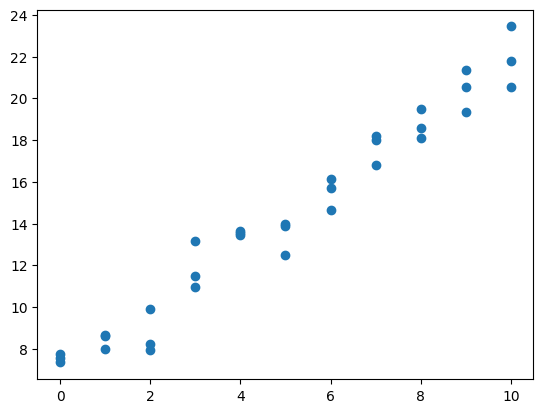

In [1]:
#import some modules needed
import matplotlib.pyplot as plt
import numpy as np
from numpy.random import default_rng

rng = default_rng(999)
beta_0 = 7
beta_1 = 1.5

# get three 'values' of x at each integer from 0 to 10.
x = np.array(list(np.linspace(start = 0, stop = 10, num = 11))*3)
n = 33

#create the 'responses' modeled from the line plus a random deviation
y = beta_0 + beta_1 * x + rng.standard_normal(n)

#visualize the data
plt.scatter(x = x, y = y)
plt.show()

Now we perform regression on the 33 generated values to find an estimate for the slope of the SLR, $\hat{\beta_1}$.

In [2]:
from sklearn.linear_model import LinearRegression

x = x.reshape((-1, 1))
reg = LinearRegression().fit(x, y)

LinearRegression()
m = reg.coef_[0]
print(m)

1.4856398973447633


Now we create use a loop to repeat this process and generate 5000 different estimates for the slope.

In [3]:
k = 5000

beta1hat = [0] * k

for i in range(k):
    # get three 'values' of x at each integer from 0 to 10.
    x = np.array(list(np.linspace(start = 0, stop = 10, num = 11))*3)
    n = 33

    #create the 'responses' modeled from the line plus a random deviation
    y = beta_0 + beta_1 * x + rng.standard_normal(n)

    x = x.reshape((-1, 1))
    reg = LinearRegression().fit(x, y)

    LinearRegression()
    beta1hat[i] = reg.coef_[0]

Now we generate a histogram of the different estimates for $\beta_1$ to examine their distribution.

<Axes: ylabel='Count'>

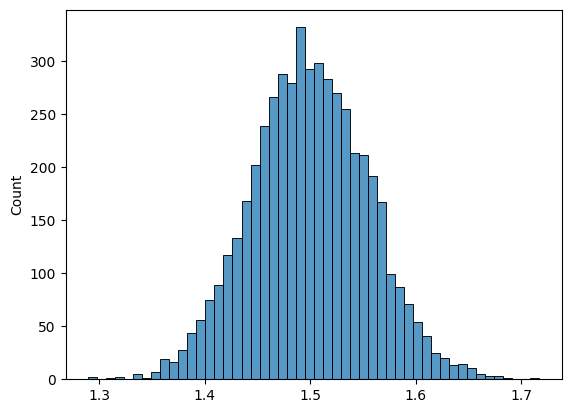

In [4]:
import seaborn as sns

sns.histplot(beta1hat)

Finally, we use the generated values to find the empirical probability $$\mathbb{P}(\hat{\beta_1} > 1.65)$$

In [5]:
probcount = 0

for i in range(k):
    if beta1hat[i] > 1.65:
        probcount += 1

print("The probability beta-1-hat is greater than 1.65 is", \
      round(probcount / k, 4))

The probability beta-1-hat is greater than 1.65 is 0.0046


This probability is much lower than, say, 0.05, so we can say it is statistically significant. In a hypothesis test, we could conclude a value for $\beta_1$ greater than 1.65 is "unusual."

# Part III - Big Data Examples & Rare Events

## Question 5

# Part IV - Querying a database

For this part, we will use an external database (stored locally in Colab) containing information regarding baseball.

## Question 8

First we read in the data and store it as a data frame.

In [6]:
import pandas as pd
import sqlite3


# in-memory (local) database
con = sqlite3.connect("lahman_1871-2022.sqlite")

#create a 'cursor' object from our connection
cursor = con.cursor()

#SQL query to return all table names in the data base
#The * indicates we want to select everything
get_schema = '''
        SELECT *
        FROM sqlite_schema
        WHERE type = "table";
        '''

#execute the SQL query on the database!
cursor.execute(get_schema)

# read the table in as a dataframe and view it
baseball = pd.read_sql(get_schema, con)
baseball

,type,name,tbl_name,rootpage,sql
0,table,AllstarFull,AllstarFull,2,"CREATE TABLE AllstarFull (\nplayerID TEXT,\nye..."
1,table,Appearances,Appearances,3,"CREATE TABLE Appearances (\nyearID INTEGER,\nt..."
2,table,AwardsManagers,AwardsManagers,4,"CREATE TABLE AwardsManagers (\nplayerID TEXT,\..."
3,table,AwardsPlayers,AwardsPlayers,5,"CREATE TABLE AwardsPlayers (\nplayerID TEXT,\n..."
4,table,AwardsShareManagers,AwardsShareManagers,6,CREATE TABLE AwardsShareManagers (\nawardID TE...
5,table,AwardsSharePlayers,AwardsSharePlayers,7,CREATE TABLE AwardsSharePlayers (\nawardID TEX...
6,table,Batting,Batting,8,"CREATE TABLE Batting (\nplayerID TEXT,\nyearID..."
7,table,BattingPost,BattingPost,9,"CREATE TABLE BattingPost (\nyearID INTEGER,\nr..."
8,table,CollegePlaying,CollegePlaying,10,"CREATE TABLE CollegePlaying (\nplayerID TEXT,\..."
9,table,Fielding,Fielding,11,"CREATE TABLE Fielding (\nplayerID TEXT,\nyearI..."


## Question 9

Next  we return all the teams that played in the year 2015 with all the corresponding columns from the `Teams` table. Note the appropriate year column name is given from the `sql` column in the `Teams` row as `yearID`.

In [7]:
q9query = '''
        SELECT *
        FROM "Teams"
        WHERE yearID = "2015";
        '''

#execute the SQL query on the database!
cursor.execute(q9query)

# read the table in as a dataframe and view it
teams2015 = pd.read_sql(q9query, con)
teams2015

,yearID,lgID,teamID,franchID,divID,Rank,G,Ghome,W,L,...,DP,FP,name,park,attendance,BPF,PPF,teamIDBR,teamIDlahman45,teamIDretro
0,2015,AL,BAL,BAL,E,3,162,78,81,81,...,134,0.987,Baltimore Orioles,Oriole Park at Camden Yards,2281202,103,104,BAL,BAL,BAL
1,2015,AL,BOS,BOS,E,5,162,81,78,84,...,148,0.984,Boston Red Sox,Fenway Park II,2880694,104,107,BOS,BOS,BOS
2,2015,AL,CHA,CHW,C,4,162,81,76,86,...,159,0.983,Chicago White Sox,U.S. Cellular Field,1755810,92,93,CHW,CHA,CHA
3,2015,AL,CLE,CLE,C,3,161,80,81,80,...,136,0.987,Cleveland Indians,Progressive Field,1388905,106,106,CLE,CLE,CLE
4,2015,AL,DET,DET,C,5,161,81,74,87,...,165,0.986,Detroit Tigers,Comerica Park,2726048,97,98,DET,DET,DET
5,2015,AL,HOU,HOU,W,2,162,81,86,76,...,131,0.986,Houston Astros,Minute Maid Park,2153585,97,99,HOU,HOU,HOU
6,2015,AL,KCA,KCR,C,1,162,81,95,67,...,138,0.985,Kansas City Royals,Kauffman Stadium,2708549,104,103,KCR,KCA,KCA
7,2015,AL,LAA,ANA,W,3,162,81,85,77,...,108,0.984,Los Angeles Angels of Anaheim,Angel Stadium of Anaheim,3012765,94,95,LAA,ANA,ANA
8,2015,AL,MIN,MIN,C,2,162,81,83,79,...,150,0.986,Minnesota Twins,Target Field,2220054,103,104,MIN,MIN,MIN
9,2015,AL,NYA,NYY,E,2,162,81,87,75,...,135,0.985,New York Yankees,Yankee Stadium III,3193795,99,101,NYY,NYA,NYA


## Question 10

Now we return all the players in the hall of fame, the year they were voted into the hall of fame, and their category.

In [8]:
q10query = '''
        SELECT playerID, yearid, category
        FROM "HallOfFame"
        WHERE inducted = "Y"
        '''

#execute the SQL query on the database!
cursor.execute(q10query)

# read the table in as a dataframe and view it
hallOfFame = pd.read_sql(q10query, con)
hallOfFame

,playerID,yearid,category
0,aaronha01,1982,Player
1,alexape01,1938,Player
2,alomaro01,2011,Player
3,alstowa01,1983,Manager
4,andersp01,2000,Manager
...,...,...,...
335,yastrca01,1989,Player
336,yawketo99,1980,Pioneer/Executive
337,youngcy01,1937,Player
338,youngro01,1972,Player


## Question 11

Next we return all unique managers of the Pittsburg Pirates and only that information from the `Managers` table.

In [9]:
q11query = '''
        SELECT DISTINCT playerID
        FROM "Managers"
        WHERE teamID = "PIT"
        '''

#execute the SQL query on the database!
cursor.execute(q11query)

# read the table in as a dataframe and view it
piratesManagers = pd.read_sql(q11query, con)
piratesManagers

,playerID
0,bezdehu99
1,bragabo01
2,buckeal99
3,burnsto01
4,burwebi01
5,bushdo01
6,callani01
7,clarkfr01
8,davissp01
9,donovpa01


Now we use the `HallOfFame` and `Managers` tables to return all of the `playerID`s for the people that managed for a team that were also inducted into the hall of fame.

In [21]:
q12query1 = """
  SELECT DISTINCT hall.playerID
  FROM "HallOfFame" AS hall
  INNER JOIN Managers AS man
  ON hall.playerID = man.playerID
  """

# read the table in as a dataframe and view it
hallOfFameManagers = pd.read_sql(q12query1, con)
hallOfFameManagers

,playerID
0,allisdo01
1,alomasa02
2,aloufe01
3,alstowa01
4,andersp01
...,...
245,wrighge01
246,wrighha01
247,yorkru01
248,youngcy01


We indicate the number of such players:

In [22]:
q12query2 = """
  SELECT COUNT( DISTINCT hall.playerID )
  FROM "HallOfFame" AS hall
  INNER JOIN Managers AS man
  ON hall.playerID = man.playerID
  """

pd.read_sql(q12query2, con)

,COUNT( DISTINCT hall.playerID )
0,250


## Question 13

Next, we will use the same two tables, `HallOfFame` and `Managers`, to return every season managed by each manager that made it to the hall of fame.

In [34]:
q13query1 = """
  SELECT DISTINCT hall.playerID, man.yearID, man.G, man.W, man.L
  FROM "HallOfFame" AS hall
  INNER JOIN Managers AS man
  ON hall.playerID = man.playerID
  """

# read the table in as a dataframe and view it
hallOfFameManagersFull = pd.read_sql(q13query1, con)
hallOfFameManagersFull

,playerID,yearID,G,W,L
0,allisdo01,1873,23,2,21
1,alomasa02,2012,6,3,3
2,alomasa02,2020,7,5,2
3,aloufe01,1992,125,70,55
4,aloufe01,1993,162,94,68
...,...,...,...,...,...
1754,wrighha01,1892,155,87,66
1755,wrighha01,1893,133,72,57
1756,yorkru01,1959,1,0,1
1757,youngcy01,1907,6,3,3


Next, we determine the overall win/loss records for each of these hall of fame managers.

In [59]:
# sum wins and losses per player and group by the player

q13query2 = """
  SELECT DISTINCT hall.playerID, SUM(man.W), SUM(man.L)
  FROM "HallOfFame" AS hall
  INNER JOIN Managers AS man
  ON hall.playerID = man.playerID
  GROUP BY hall.playerID
  """

# read the table in as a dataframe and view it
hallOfFameManagersRecord = pd.read_sql(q13query2, con)
hallOfFameManagersRecord

,playerID,SUM(man.W),SUM(man.L)
0,allisdo01,2,21
1,alomasa02,8,5
2,aloufe01,1033,1020
3,alstowa01,2040,1613
4,andersp01,2194,1834
...,...,...,...
245,wrighge01,118,50
246,wrighha01,1225,885
247,yorkru01,0,2
248,youngcy01,9,9


Then we create a new variable that is the win/loss percentage.

In [60]:
# must multiply the W column by 1.0 to change from integer division to float
# division

q13query3 = """
  SELECT DISTINCT hall.playerID, (man.W * 1.0 / man.G) AS "W/G"
  FROM "HallOfFame" AS hall
  INNER JOIN Managers AS man
  ON hall.playerID = man.playerID
  GROUP BY man.playerID
  """

# read the table in as a dataframe and view it
hallOfFameManagersProp = pd.read_sql(q13query3, con)
hallOfFameManagersProp

,playerID,W/G
0,allisdo01,0.086957
1,alomasa02,0.500000
2,aloufe01,0.560000
3,alstowa01,0.597403
4,andersp01,0.629630
...,...,...
245,wrighge01,0.694118
246,wrighha01,0.645161
247,yorkru01,0.000000
248,youngcy01,0.500000


Finally, we sort the resulting data from largest to smallest and conclude by closing the cursor.

In [61]:
# must multiply the W column by 1.0 to change from integer division to float
# division

q13query3 = """
  SELECT DISTINCT hall.playerID, (man.W * 1.0 / man.G) AS "W/G"
  FROM "HallOfFame" AS hall
  INNER JOIN Managers AS man
  ON hall.playerID = man.playerID
  GROUP BY man.playerID
  ORDER BY "W/G" DESC
  """

# read the table in as a dataframe and view it
hallOfFameManagersProp = pd.read_sql(q13query3, con)
hallOfFameManagersProp

,playerID,W/G
0,hardeme01,1.000000
1,kuennha01,1.000000
2,randowi01,1.000000
3,simmote01,1.000000
4,speiech01,1.000000
...,...,...
245,allisdo01,0.086957
246,lathaar01,0.000000
247,loberha01,0.000000
248,whitede01,0.000000


In [62]:
# close the cursor
cursor.close()